<a href="https://colab.research.google.com/github/jellybbie/study/blob/project1/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [ ]:
import pandas as pd

excel_file_path = '/content/screening(2025)-4.xlsx'
df = pd.read_excel(excel_file_path)
display(df.head())

,96well Name,Location in 96well,Strain,IAA production,Cytokinin production,ACC deaminase activity,Phosphate solubilization,Nitrogen fixation
0,콩 내생분리균 1-1,A1,RMR-1,1.1787,0.1084,0.0488,0.4534,0.1425
1,콩 내생분리균 1-1,A2,RMR-2,1.0249,0.1206,0.0491,0.6858,0.1628
2,콩 내생분리균 1-1,A3,RMR-3,0.9659,0.1164,0.0486,0.7367,0.1588
3,콩 내생분리균 1-1,A4,RMR-4,1.2435,0.1166,0.0469,0.6707,0.1565
4,콩 내생분리균 1-1,A5,RMR-5,0.9413,0.1391,0.0857,0.7560,0.2239


In [ ]:
import numpy as np

# Define the characteristic columns
characteristic_cols = [
    'IAA production',
    'Cytokinin production',
    'ACC deaminase activity',
    'Phosphate solubilization',
    'Nitrogen fixation'
]

# Check for duplicate strains in the 'Strain' column
duplicate_strains_count = df['Strain'].duplicated().sum()

if duplicate_strains_count > 0:
    print(f"Found {duplicate_strains_count} duplicate strain entries. Aggregating data by taking the mean for each characteristic.")
    # Group by 'Strain' and calculate the mean for the characteristic columns
    processed_df = df.groupby('Strain')[characteristic_cols].mean().reset_index()
else:
    print("No duplicate strains found. Using the original DataFrame for analysis.")
    processed_df = df.copy()

print(f"\nTotal unique or aggregated strains for analysis: {len(processed_df)}")


Found 119 duplicate strain entries. Aggregating data by taking the mean for each characteristic.

Total unique or aggregated strains for analysis: 1688


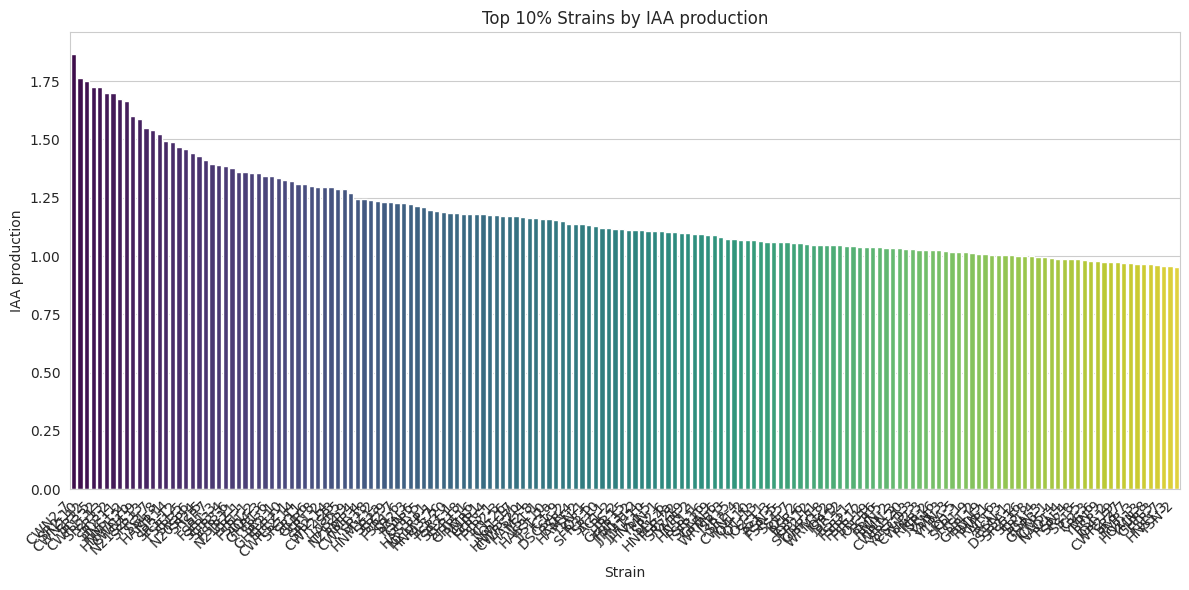

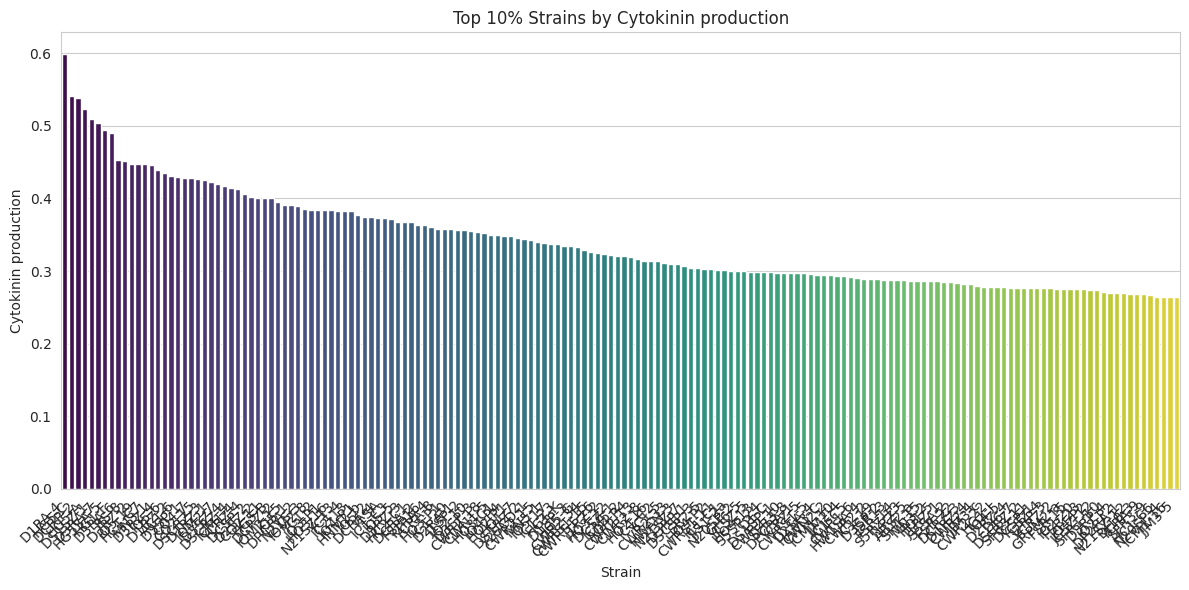

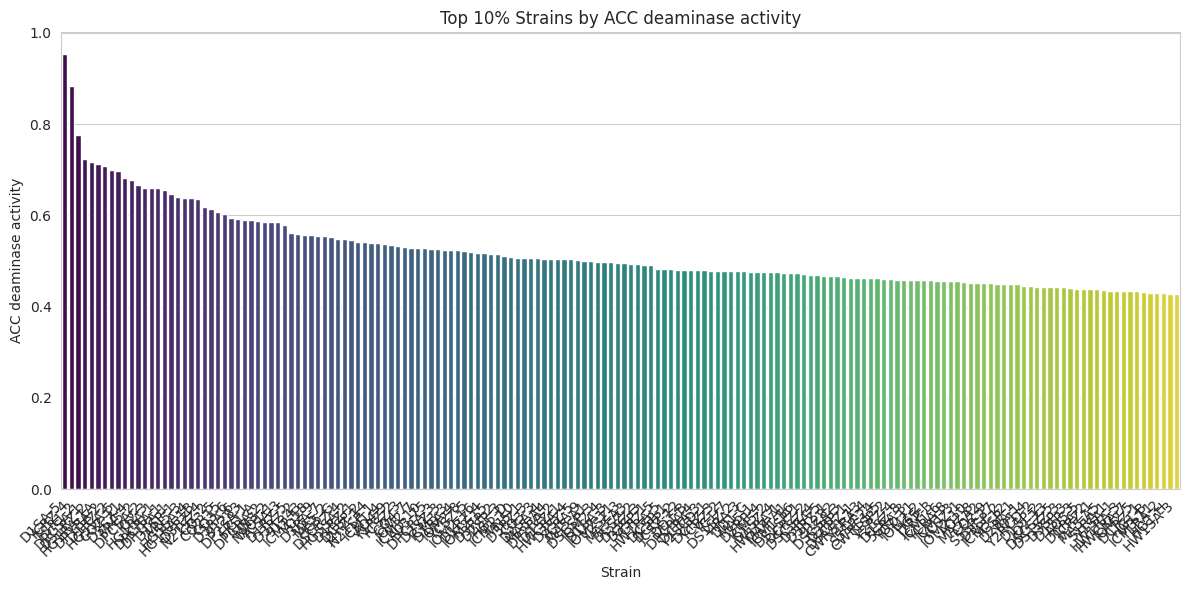

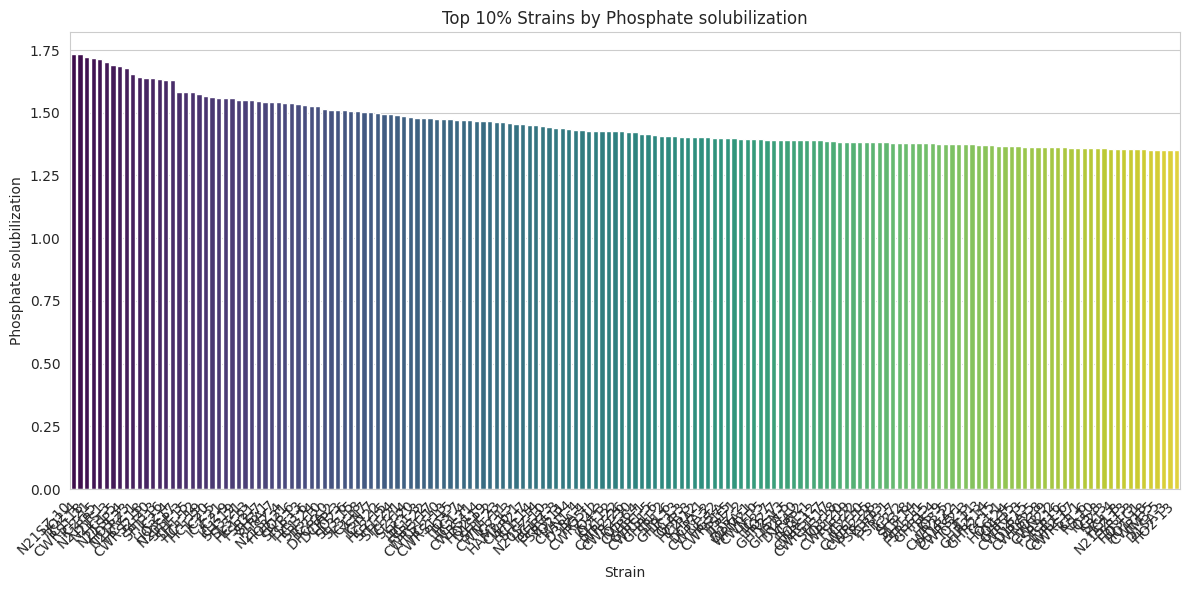

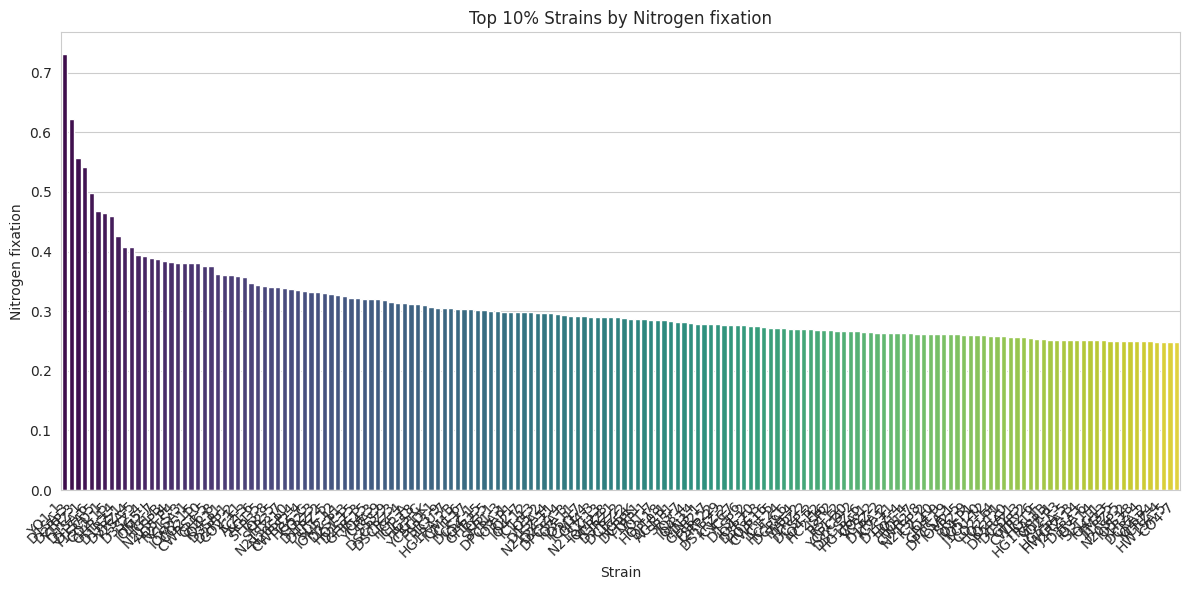

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming characteristic_cols and processed_df are already defined from previous steps

for col in characteristic_cols:
    # Calculate the number of top strains (10%)
    num_top_strains = max(1, int(len(processed_df) * 0.10))

    # Sort by the current characteristic in descending order and select the top strains
    top_strains = processed_df.sort_values(by=col, ascending=False).head(num_top_strains)

    # Create a bar plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Strain', y=col, data=top_strains, palette='viridis', hue='Strain', legend=False)
    plt.title(f'Top 10% Strains by {col}')
    plt.xlabel('Strain')
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

excel_file_path = '/content/screening(2025)-4.xlsx'
df = pd.read_excel(excel_file_path)

characteristic_cols = [
    'IAA production',
    'Cytokinin production',
    'ACC deaminase activity',
    'Phosphate solubilization',
    'Nitrogen fixation'
]

duplicate_strains_count = df['Strain'].duplicated().sum()

if duplicate_strains_count > 0:
    processed_df = df.groupby('Strain')[characteristic_cols].mean().reset_index()
else:
    processed_df = df.copy()

acc_deaminase_col = 'ACC deaminase activity'
num_top_strains_acc = max(1, int(len(processed_df) * 0.10))
top_strains_acc = processed_df.sort_values(by=acc_deaminase_col, ascending=False).head(num_top_strains_acc)
print(f"Top {num_top_strains_acc} Strains by {acc_deaminase_col}:")
display(top_strains_acc[['Strain', acc_deaminase_col]])

Top 168 Strains by ACC deaminase activity:


,Strain,ACC deaminase activity
308,D1SA-5,0.9536
1626,YCRZ-4,0.8833
494,FSR1-2,0.7771
427,DPCSA-1,0.7240
437,DS1RZ-2,0.7161
...,...,...
701,HG1-B,0.4303
964,ICM3-11,0.4294
1567,Y1RA-2,0.4288
707,HG1-H,0.4283


In [ ]:
strains_above_0_4 = top_strains_acc[top_strains_acc[acc_deaminase_col] >= 0.4]
num_strains_above_0_4 = len(strains_above_0_4)
print(f"Number of strains with {acc_deaminase_col} >= 0.4: {num_strains_above_0_4}")
display(strains_above_0_4[['Strain', acc_deaminase_col]])

Number of strains with ACC deaminase activity >= 0.4: 168


,Strain,ACC deaminase activity
308,D1SA-5,0.9536
1626,YCRZ-4,0.8833
494,FSR1-2,0.7771
427,DPCSA-1,0.7240
437,DS1RZ-2,0.7161
...,...,...
701,HG1-B,0.4303
964,ICM3-11,0.4294
1567,Y1RA-2,0.4288
707,HG1-H,0.4283


In [ ]:
other_characteristics = [
    'IAA production',
    'Cytokinin production',
    'Phosphate solubilization',
    'Nitrogen fixation'
]

# Filter strains where all other characteristics are also >= 0.4
multi_criteria_strains = strains_above_0_4.copy()
for col in other_characteristics:
    multi_criteria_strains = multi_criteria_strains[multi_criteria_strains[col] >= 0.4]

num_multi_criteria_strains = len(multi_criteria_strains)
print(f"Number of strains with ACC deaminase activity >= 0.4 AND all other 4 characteristics >= 0.4: {num_multi_criteria_strains}")
display(multi_criteria_strains[['Strain'] + other_characteristics + ['ACC deaminase activity']])

Number of strains with ACC deaminase activity >= 0.4 AND all other 4 characteristics >= 0.4: 0


,Strain,IAA production,Cytokinin production,Phosphate solubilization,Nitrogen fixation,ACC deaminase activity


In [ ]:
other_characteristics_cols = [
    'IAA production',
    'Cytokinin production',
    'Phosphate solubilization',
    'Nitrogen fixation'
]

# Filter strains where at least one of the other characteristics is >= 0.4
# We use `any(axis=1)` to check if at least one condition is True across the specified columns
conditional_strains = strains_above_0_4[
    (strains_above_0_4[other_characteristics_cols] >= 0.4).any(axis=1)
]

num_conditional_strains = len(conditional_strains)
print(f"Number of strains with ACC deaminase activity >= 0.4 AND at least one of the other 4 characteristics >= 0.4: {num_conditional_strains}")
display(conditional_strains[['Strain'] + other_characteristics_cols + ['ACC deaminase activity']])

Number of strains with ACC deaminase activity >= 0.4 AND at least one of the other 4 characteristics >= 0.4: 168


,Strain,IAA production,Cytokinin production,Phosphate solubilization,Nitrogen fixation,ACC deaminase activity
308,D1SA-5,0.3212,0.2464,1.0441,0.4672,0.9536
1626,YCRZ-4,0.2563,0.4062,1.0977,0.2485,0.8833
494,FSR1-2,1.3544,0.1741,0.7866,0.1372,0.7771
427,DPCSA-1,0.2540,0.1802,0.8105,0.2612,0.7240
437,DS1RZ-2,0.2661,0.3437,0.8065,0.2765,0.7161
...,...,...,...,...,...,...
701,HG1-B,0.6330,0.1820,1.3561,0.3835,0.4303
964,ICM3-11,0.3265,0.2522,0.7253,0.1834,0.4294
1567,Y1RA-2,0.9166,0.1944,0.5146,0.2020,0.4288
707,HG1-H,0.2000,0.1051,0.9095,0.1513,0.4283


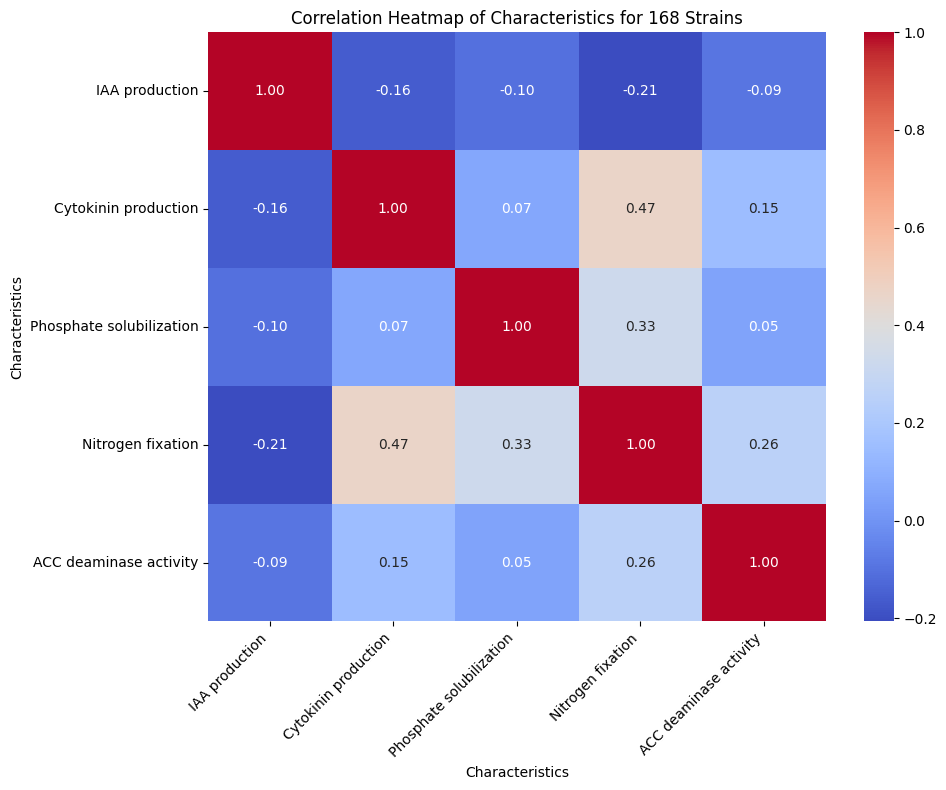

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all relevant characteristic columns for correlation analysis
correlation_cols = other_characteristics_cols + [acc_deaminase_col]

# Calculate the correlation matrix
correlation_matrix = conditional_strains[correlation_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Characteristics for 168 Strains')
plt.xlabel('Characteristics')
plt.ylabel('Characteristics')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()